<a href="https://colab.research.google.com/github/nguoitinhmuadong-1/AI_CK/blob/main/train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau



In [ ]:
dataset_path = "/content/drive/MyDrive/FoodDataset"

print(os.listdir(dataset_path))

['thit_kho', 'rau_xao', 'trung_chien', 'suon_nuong', 'ca_hu_kho', 'com_trang', 'dau_hu_sot_ca', 'canh_chua', 'canh_rau', 'thit_kho_trung']


In [ ]:
CLASS_NAMES = [
    "ca_hu_kho",
    "canh_chua",
    "canh_rau",
    "com_trang",
    "dau_hu_sot_ca",
    "rau_xao",
    "suon_nuong",
    "thit_kho",
    "thit_kho_trung",
    "trung_chien"
]

num_classes = len(CLASS_NAMES)

print("Số class:", num_classes)
print("Class names:", CLASS_NAMES)

Số class: 10
Class names: ['ca_hu_kho', 'canh_chua', 'canh_rau', 'com_trang', 'dau_hu_sot_ca', 'rau_xao', 'suon_nuong', 'thit_kho', 'thit_kho_trung', 'trung_chien']


In [ ]:
train_dir = "/content/drive/MyDrive/FoodDataset"

img_width, img_height = 224, 224
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    classes=CLASS_NAMES,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    classes=CLASS_NAMES,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
print("Tổng ảnh train:", train_generator.samples)
print("Tổng ảnh val:", val_generator.samples)

Found 5165 images belonging to 10 classes.
Found 5165 images belonging to 10 classes.
Class indices: {'ca_hu_kho': 0, 'canh_chua': 1, 'canh_rau': 2, 'com_trang': 3, 'dau_hu_sot_ca': 4, 'rau_xao': 5, 'suon_nuong': 6, 'thit_kho': 7, 'thit_kho_trung': 8, 'trung_chien': 9}
Tổng ảnh train: 5165
Tổng ảnh val: 5165


In [ ]:
class_counts = np.bincount(train_generator.classes)
total_samples = len(train_generator.classes)

class_weights = {}

for i in range(num_classes):
    if class_counts[i] > 0:
        class_weights[i] = total_samples / (num_classes * class_counts[i])
    else:
        class_weights[i] = 1.0

print("Số ảnh từng class:")

for i, name in enumerate(CLASS_NAMES):
    print(f"{i} - {name}: {class_counts[i]} ảnh | weight = {class_weights[i]:.3f}")

Số ảnh từng class:
0 - ca_hu_kho: 497 ảnh | weight = 1.039
1 - canh_chua: 525 ảnh | weight = 0.984
2 - canh_rau: 512 ảnh | weight = 1.009
3 - com_trang: 501 ảnh | weight = 1.031
4 - dau_hu_sot_ca: 516 ảnh | weight = 1.001
5 - rau_xao: 584 ảnh | weight = 0.884
6 - suon_nuong: 515 ảnh | weight = 1.003
7 - thit_kho: 514 ảnh | weight = 1.005
8 - thit_kho_trung: 500 ảnh | weight = 1.033
9 - trung_chien: 501 ảnh | weight = 1.031


In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(img_width, img_height, 3)
)

base_model.trainable = False

In [ ]:
model = Sequential([
    base_model,

    GlobalAveragePooling2D(),
    BatchNormalization(),

    Dense(256, activation="relu"),
    Dropout(0.5),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625,226 (10.01 MB)

 Trainable params: 364,682 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_food_mobilenetv2.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr_stage1 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks_stage1 = [checkpoint, reduce_lr_stage1]

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    class_weight=class_weights,
    callbacks=callbacks_stage1
)

Epoch 1/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.4956 - loss: 1.6504
Epoch 1: val_accuracy improved from None to 0.88596, saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5
162/162 ━━━━━━━━━━━━━━━━━━━━ 1718s 11s/step - accuracy: 0.6439 - loss: 1.1395 - val_accuracy: 0.8860 - val_loss: 0.3520 - learning_rate: 0.0010
Epoch 2/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7892 - loss: 0.6416
Epoch 2: val_accuracy improved from 0.88596 to 0.92236, saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5
162/162 ━━━━━━━━━━━━━━━━━━━━ 583s 4s/step - accuracy: 0.8029 - loss: 0.6215 - val_accuracy: 0.9224 - val_loss: 0.2422 - learning_rate: 0.0010
Epoch 3/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8351 - loss: 0.5184
Epoch 3: val_accuracy did not improve from 0.92236
162/162 ━━━━━━━━━━━━━━━━━━━━ 585s 4s/step - accuracy: 0.8379 - loss: 0.5055 - val_accuracy: 0.9158 - val_loss: 0.2442 - learning_rate: 0.0010
Epoch 4/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8584 - loss: 0.4480
Epoch 4: val_accuracy improved from 0.92236 to 0.93785, saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5



Epoch 4: finished saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5
162/162 ━━━━━━━━━━━━━━━━━━━━ 581s 4s/step - accuracy: 0.8577 - loss: 0.4618 - val_accuracy: 0.9379 - val_loss: 0.1888 - learning_rate: 0.0010
Epoch 5/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8808 - loss: 0.3887
Epoch 5: val_accuracy improved from 0.93785 to 0.94327, saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5



Epoch 5: finished saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5
162/162 ━━━━━━━━━━━━━━━━━━━━ 578s 4s/step - accuracy: 0.8711 - loss: 0.4056 - val_accuracy: 0.9433 - val_loss: 0.1676 - learning_rate: 0.0010
Epoch 6/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8773 - loss: 0.3989
Epoch 6: val_accuracy did not improve from 0.94327
162/162 ━━━━━━━━━━━━━━━━━━━━ 579s 4s/step - accuracy: 0.8809 - loss: 0.3759 - val_accuracy: 0.9417 - val_loss: 0.1629 - learning_rate: 0.0010
Epoch 7/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8848 - loss: 0.3627
Epoch 7: val_accuracy improved from 0.94327 to 0.94947, saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5


...


Epoch 41: finished saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5
162/162 ━━━━━━━━━━━━━━━━━━━━ 580s 4s/step - accuracy: 0.9580 - loss: 0.1390 - val_accuracy: 0.9766 - val_loss: 0.0661 - learning_rate: 3.0000e-04
Epoch 42/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9543 - loss: 0.1376
Epoch 42: val_accuracy improved from 0.97657 to 0.97832, saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5



Epoch 42: finished saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5
162/162 ━━━━━━━━━━━━━━━━━━━━ 566s 3s/step - accuracy: 0.9574 - loss: 0.1343 - val_accuracy: 0.9783 - val_loss: 0.0638 - learning_rate: 3.0000e-04
Epoch 43/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9604 - loss: 0.1171
Epoch 43: val_accuracy did not improve from 0.97832
162/162 ━━━━━━━━━━━━━━━━━━━━ 580s 4s/step - accuracy: 0.9553 - loss: 0.1381 - val_accuracy: 0.9781 - val_loss: 0.0668 - learning_rate: 3.0000e-04
Epoch 44/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9533 - loss: 0.1447
Epoch 44: val_accuracy did not improve from 0.97832
162/162 ━━━━━━━━━━━━━━━━━━━━ 576s 4s/step - accuracy: 0.9566 - loss: 0.1367 - val_accuracy: 0.9777 - val_loss: 0.0626 - learning_rate: 3.0000e-04
Epoch 45/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9653 - loss: 0.1160
Epoch 45: val_accuracy improved from 0.97832 to 0.97928, saving model to /content/drive/MyDrive/best_food_mobilenetv


Epoch 45: finished saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5
162/162 ━━━━━━━━━━━━━━━━━━━━ 570s 4s/step - accuracy: 0.9632 - loss: 0.1234 - val_accuracy: 0.9793 - val_loss: 0.0643 - learning_rate: 3.0000e-04
Epoch 46/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9655 - loss: 0.1219
Epoch 46: val_accuracy did not improve from 0.97928
162/162 ━━━━━━━━━━━━━━━━━━━━ 573s 4s/step - accuracy: 0.9595 - loss: 0.1359 - val_accuracy: 0.9775 - val_loss: 0.0666 - learning_rate: 3.0000e-04
Epoch 47/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9579 - loss: 0.1296
Epoch 47: val_accuracy improved from 0.97928 to 0.98103, saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5



Epoch 47: finished saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5
162/162 ━━━━━━━━━━━━━━━━━━━━ 571s 4s/step - accuracy: 0.9603 - loss: 0.1262 - val_accuracy: 0.9810 - val_loss: 0.0552 - learning_rate: 3.0000e-04
Epoch 48/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9602 - loss: 0.1321
Epoch 48: val_accuracy did not improve from 0.98103
162/162 ━━━━━━━━━━━━━━━━━━━━ 563s 3s/step - accuracy: 0.9593 - loss: 0.1294 - val_accuracy: 0.9808 - val_loss: 0.0587 - learning_rate: 3.0000e-04
Epoch 49/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9671 - loss: 0.1155
Epoch 49: val_accuracy did not improve from 0.98103
162/162 ━━━━━━━━━━━━━━━━━━━━ 566s 3s/step - accuracy: 0.9667 - loss: 0.1130 - val_accuracy: 0.9804 - val_loss: 0.0584 - learning_rate: 3.0000e-04
Epoch 50/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9592 - loss: 0.1212
Epoch 50: val_accuracy improved from 0.98103 to 0.98374, saving model to /content/drive/MyDrive/best_food_mobilenetv


Epoch 50: finished saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5
162/162 ━━━━━━━━━━━━━━━━━━━━ 578s 4s/step - accuracy: 0.9607 - loss: 0.1257 - val_accuracy: 0.9837 - val_loss: 0.0544 - learning_rate: 3.0000e-04


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model.save("/content/drive/MyDrive/food_stage1.h5")

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-35]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
reduce_lr_fine = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-8,
    verbose=1
)

callbacks_fine = [checkpoint, reduce_lr_fine]

In [ ]:

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks_fine
)

Epoch 1/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9600 - loss: 0.1214
Epoch 1: val_accuracy did not improve from 0.98374
162/162 ━━━━━━━━━━━━━━━━━━━━ 706s 4s/step - accuracy: 0.9570 - loss: 0.1292 - val_accuracy: 0.9642 - val_loss: 0.1118 - learning_rate: 1.0000e-05
Epoch 2/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9568 - loss: 0.1502
Epoch 2: val_accuracy did not improve from 0.98374
162/162 ━━━━━━━━━━━━━━━━━━━━ 634s 4s/step - accuracy: 0.9578 - loss: 0.1370 - val_accuracy: 0.9764 - val_loss: 0.0787 - learning_rate: 1.0000e-05
Epoch 3/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9659 - loss: 0.1121
Epoch 3: val_accuracy did not improve from 0.98374
162/162 ━━━━━━━━━━━━━━━━━━━━ 629s 4s/step - accuracy: 0.9634 - loss: 0.1153 - val_accuracy: 0.9797 - val_loss: 0.0636 - learning_rate: 1.0000e-05
Epoch 4/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9635 - loss: 0.1051
Epoch 4: val_accuracy did not improve from 0.98374
162/162 ━━━━━━━━━━


Epoch 8: finished saving model to /content/drive/MyDrive/best_food_mobilenetv2.h5
162/162 ━━━━━━━━━━━━━━━━━━━━ 636s 4s/step - accuracy: 0.9665 - loss: 0.1010 - val_accuracy: 0.9882 - val_loss: 0.0364 - learning_rate: 1.0000e-05
Epoch 9/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9680 - loss: 0.1033
Epoch 9: val_accuracy did not improve from 0.98819
162/162 ━━━━━━━━━━━━━━━━━━━━ 672s 4s/step - accuracy: 0.9686 - loss: 0.1018 - val_accuracy: 0.9833 - val_loss: 0.0504 - learning_rate: 1.0000e-05
Epoch 10/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9587 - loss: 0.1250
Epoch 10: val_accuracy did not improve from 0.98819
162/162 ━━━━━━━━━━━━━━━━━━━━ 627s 4s/step - accuracy: 0.9622 - loss: 0.1191 - val_accuracy: 0.9640 - val_loss: 0.1051 - learning_rate: 1.0000e-05
Epoch 11/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9671 - loss: 0.1049
Epoch 11: val_accuracy did not improve from 0.98819

Epoch 11: ReduceLROnPlateau reducing learning rate to 2.9999999242

In [ ]:
model.save("/content/drive/MyDrive/food_final.h5")

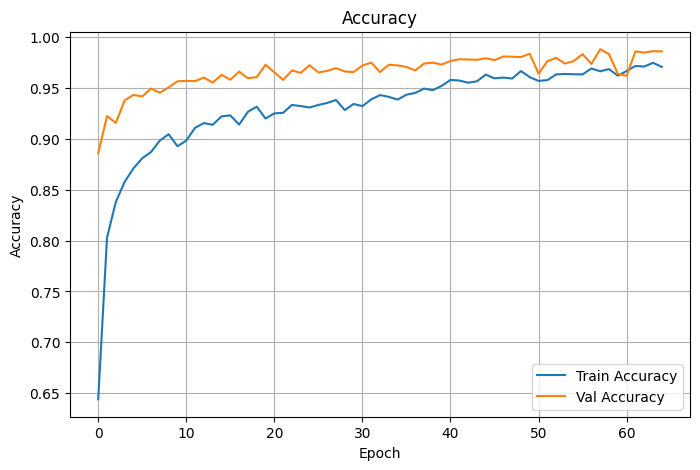

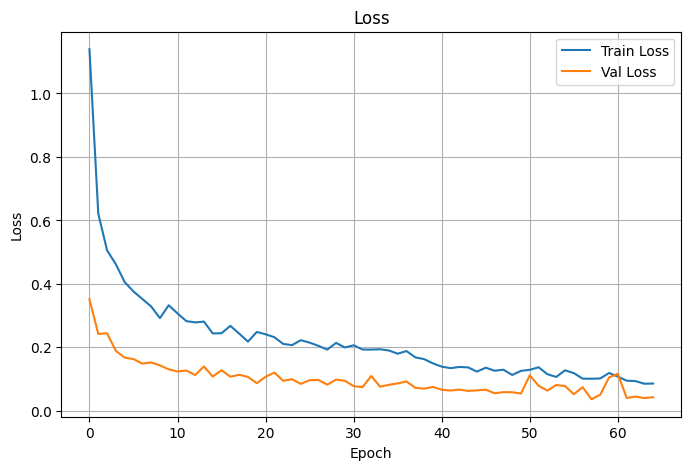

In [ ]:
acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]

loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

plt.figure(figsize=(8, 5))
plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Val Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Saving {ECF35F81-6F03-480A-8A03-651AADB3B506}.png to {ECF35F81-6F03-480A-8A03-651AADB3B506}.png


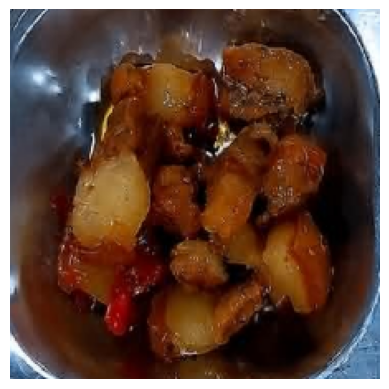

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Ảnh: {ECF35F81-6F03-480A-8A03-651AADB3B506}.png
Món dự đoán: thit_kho_trung
Độ tin cậy: 98.26%

Top 5:
thit_kho_trung: 98.26%
thit_kho: 0.92%
dau_hu_sot_ca: 0.53%
ca_hu_kho: 0.23%
canh_chua: 0.06%


In [ ]:
from google.colab import files
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Redefine CLASS_NAMES for this cell to be self-contained
CLASS_NAMES = [
    "ca_hu_kho",
    "canh_chua",
    "canh_rau",
    "com_trang",
    "dau_hu_sot_ca",
    "rau_xao",
    "suon_nuong",
    "thit_kho",
    "thit_kho_trung",
    "trung_chien"
]

# Load best model để test
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/best_food_mobilenetv2.h5",
    compile=False
)

uploaded = files.upload()

for img_path in uploaded.keys():
    img = image.load_img(img_path, target_size=(224, 224))

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # MobileNetV2 dùng preprocess_input
    # Không dùng img_array / 255.0
    img_array = preprocess_input(img_array)

    predictions = model.predict(img_array)

    predicted_class = np.argmax(predictions)
    confidence = predictions[0][predicted_class] * 100

    print("Ảnh:", img_path)
    print("Món dự đoán:", CLASS_NAMES[predicted_class])
    print("Độ tin cậy:", f"{confidence:.2f}%")

    print("\nTop 5:")
    top5 = np.argsort(predictions[0])[::-1][:5]

    for i in top5:
        print(f"{CLASS_NAMES[i]}: {predictions[0][i] * 100:.2f}%")

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

BASE_W = 1920
BASE_H = 1080

# ===== KHAY 1: 3 ô trên + 2 ô dưới =====
TRAY_TYPE_1 = {
    "top_left":     (360, 105, 675, 445),
    "top_center":   (780, 105, 1135, 445),
    "top_right":    (1265, 105, 1545, 445),
    "bottom_left":  (320, 455, 795, 985),
    "bottom_right": (930, 455, 1545, 985),
}

# ===== KHAY 2: 2 ô trên + 3 ô dưới =====
TRAY_TYPE_2 = {
    "top_left":       (325, 100, 825, 595),
    "top_right":      (1115, 100, 1535, 595),
    "bottom_left":    (330, 635, 685, 975),
    "bottom_center":  (785, 635, 1145, 975),
    "bottom_right":   (1230, 635, 1535, 975),
}
def scale_rois(rois, current_w, current_h):
    sx = current_w / BASE_W
    sy = current_h / BASE_H
    scaled = {}

    for name, (x1, y1, x2, y2) in rois.items():
        scaled[name] = (
            int(x1 * sx),
            int(y1 * sy),
            int(x2 * sx),
            int(y2 * sy)
        )

    return scaled

def get_rois(image_rgb, tray_type="tray1"):
    h, w = image_rgb.shape[:2]
    if tray_type == "tray1":
        return scale_rois(TRAY_TYPE_1, w, h)
    else:
        return scale_rois(TRAY_TYPE_2, w, h)

def draw_rois(image_rgb, rois):
    img = image_rgb.copy()
    for name, (x1, y1, x2, y2) in rois.items():
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 100, 0), 5)
        cv2.putText(
            img, name,
            (x1, max(30, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (255, 100, 0),
            3
        )
    return img

def crop_cells(image_rgb, rois):
    crops = {}
    for name, (x1, y1, x2, y2) in rois.items():
        crops[name] = image_rgb[y1:y2, x1:x2]
    return crops

def show_crops(crops):
    n = len(crops)
    plt.figure(figsize=(16, 6))
    for i, (name, crop) in enumerate(crops.items()):
        plt.subplot(1, n, i + 1)
        plt.imshow(crop)
        plt.title(name)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

Saving WIN_20260617_10_28_08_Pro.jpg to WIN_20260617_10_28_08_Pro (4).jpg
Kích thước ảnh: (1080, 1920, 3)


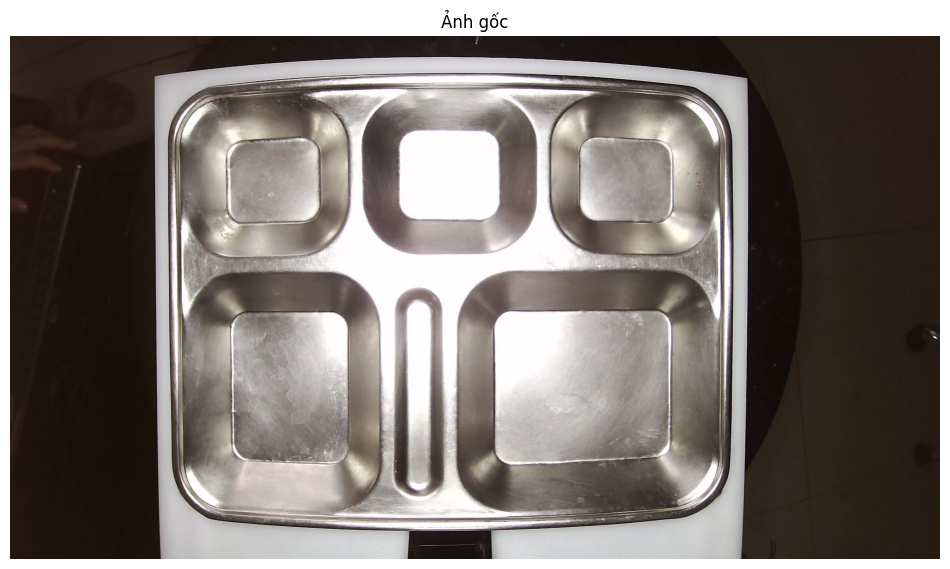

In [ ]:
# =========================
# 5. UPLOAD ẢNH TEST
# =========================

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

image = Image.open(img_path).convert("RGB")
image_rgb = np.array(image)

print("Kích thước ảnh:", image_rgb.shape)

plt.figure(figsize=(12, 7))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Ảnh gốc")
plt.show()

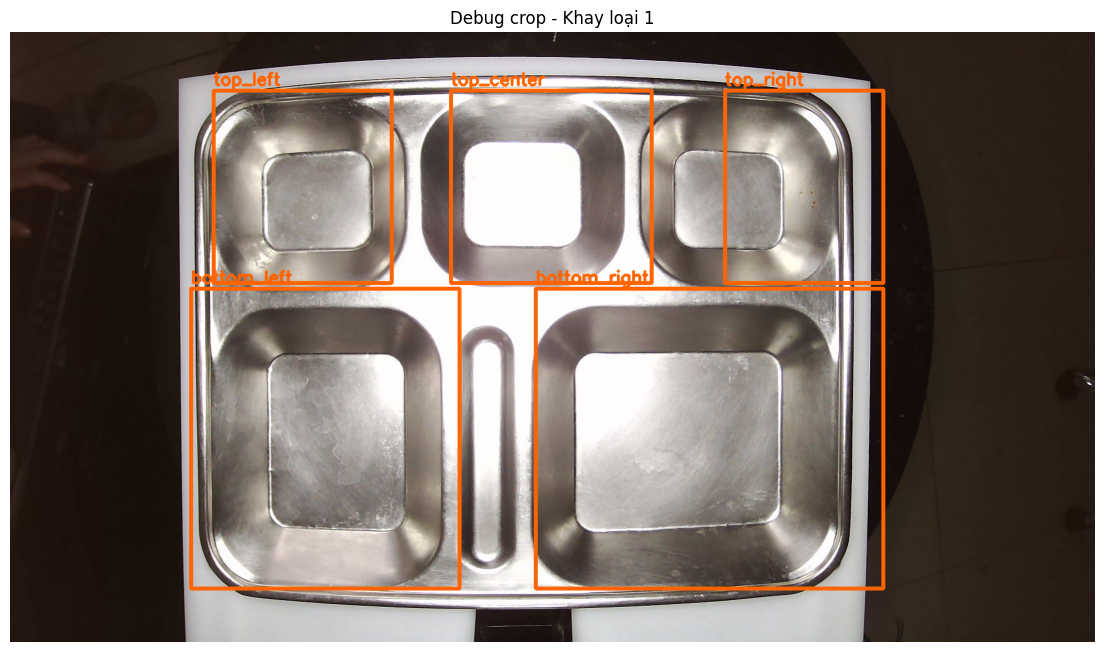

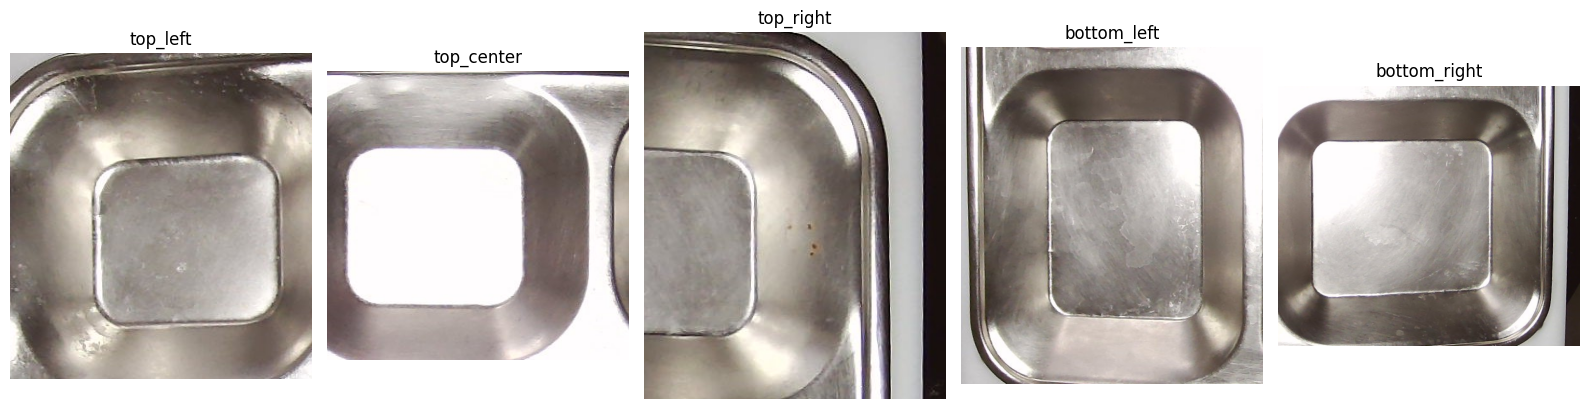

In [ ]:
tray_type = "tray1"

rois = get_rois_by_tray_type(image_rgb, tray_type)
debug_img = draw_rois(image_rgb, rois)
crops = crop_cells(image_rgb, rois)

plt.figure(figsize=(14, 8))
plt.imshow(debug_img)
plt.axis("off")
plt.title("Debug crop - Khay loại 1")
plt.show()

show_crops(crops)

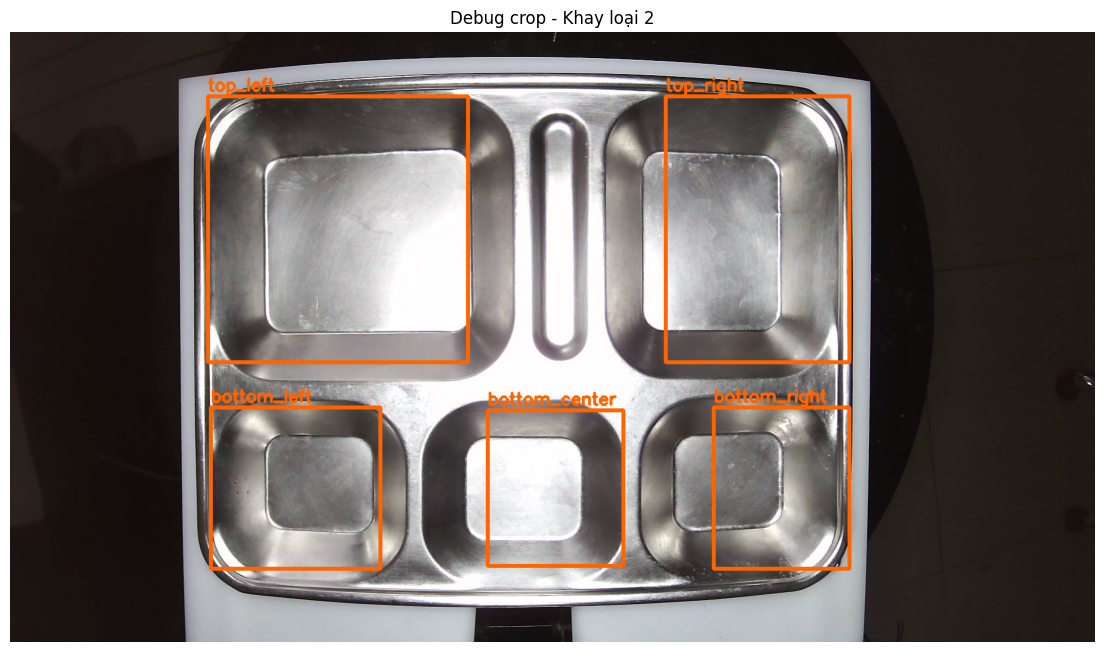

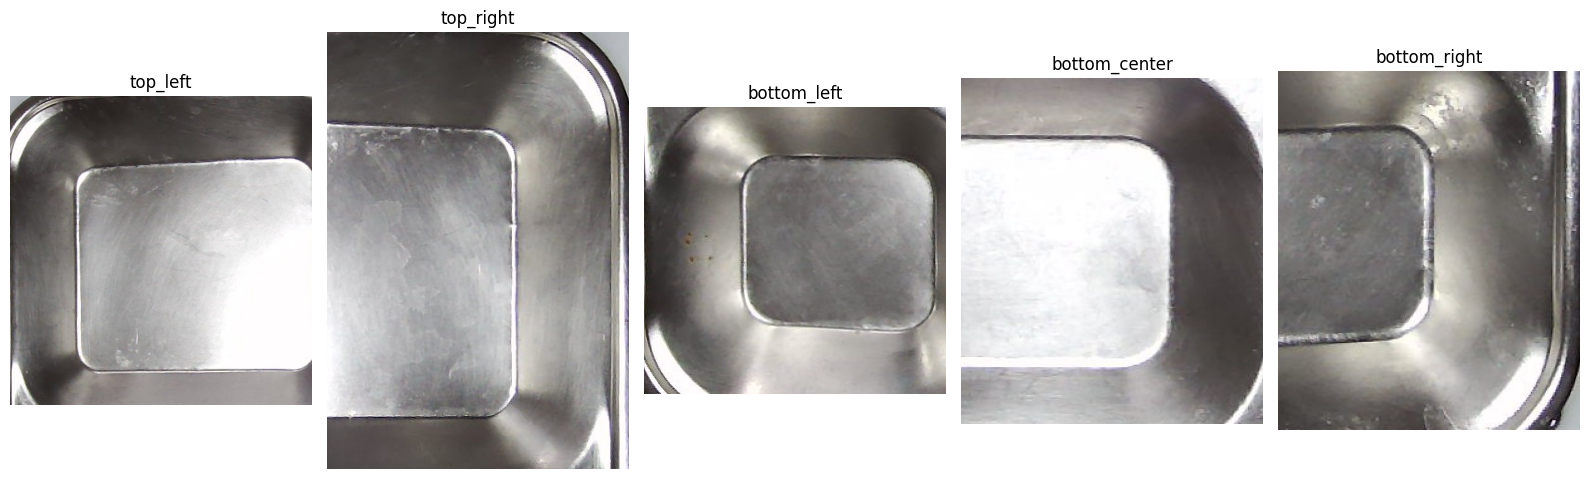

In [ ]:
tray_type = "tray2"

rois = get_rois_by_tray_type(image_rgb, tray_type)
debug_img = draw_rois(image_rgb, rois)
crops = crop_cells(image_rgb, rois)

plt.figure(figsize=(14, 8))
plt.imshow(debug_img)
plt.axis("off")
plt.title("Debug crop - Khay loại 2")
plt.show()

show_crops(crops)

Saving WIN_20260617_10_27_37_Pro.jpg to WIN_20260617_10_27_37_Pro (4).jpg
Tên ảnh: WIN_20260617_10_27_37_Pro (4).jpg
Kích thước ảnh: (1080, 1920, 3)


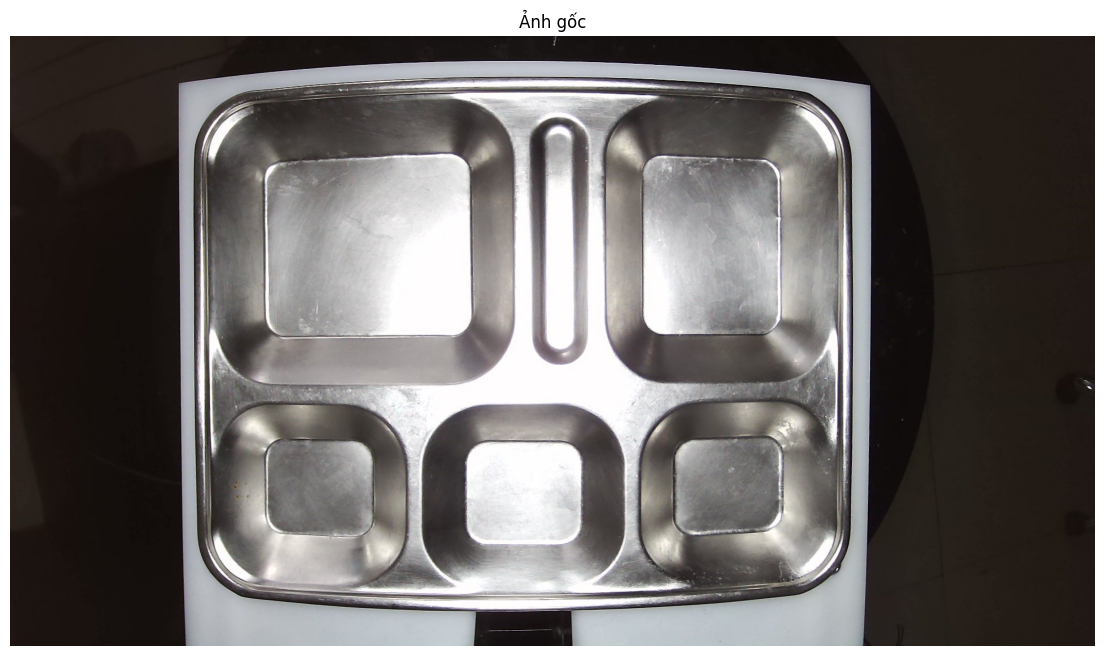

Tọa độ sau khi scale:
top_left : (392, 128, 902, 617)
top_right : (1044, 136, 1440, 626)
bottom_left : (369, 641, 696, 952)
bottom_center : (720, 647, 1096, 958)
bottom_right : (1113, 640, 1435, 924)


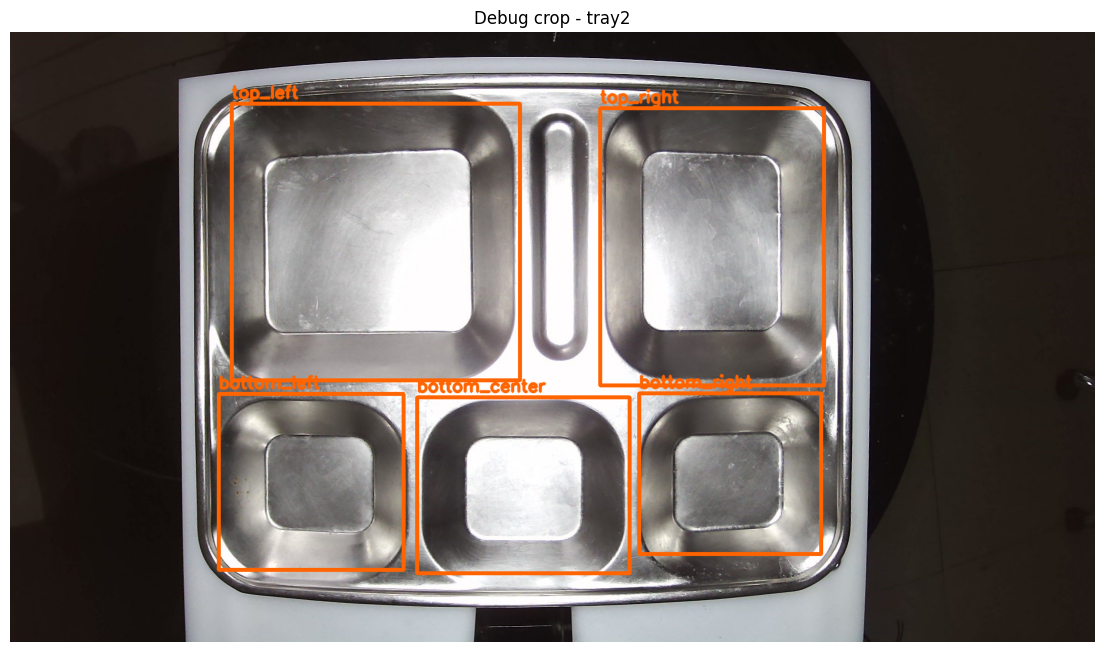

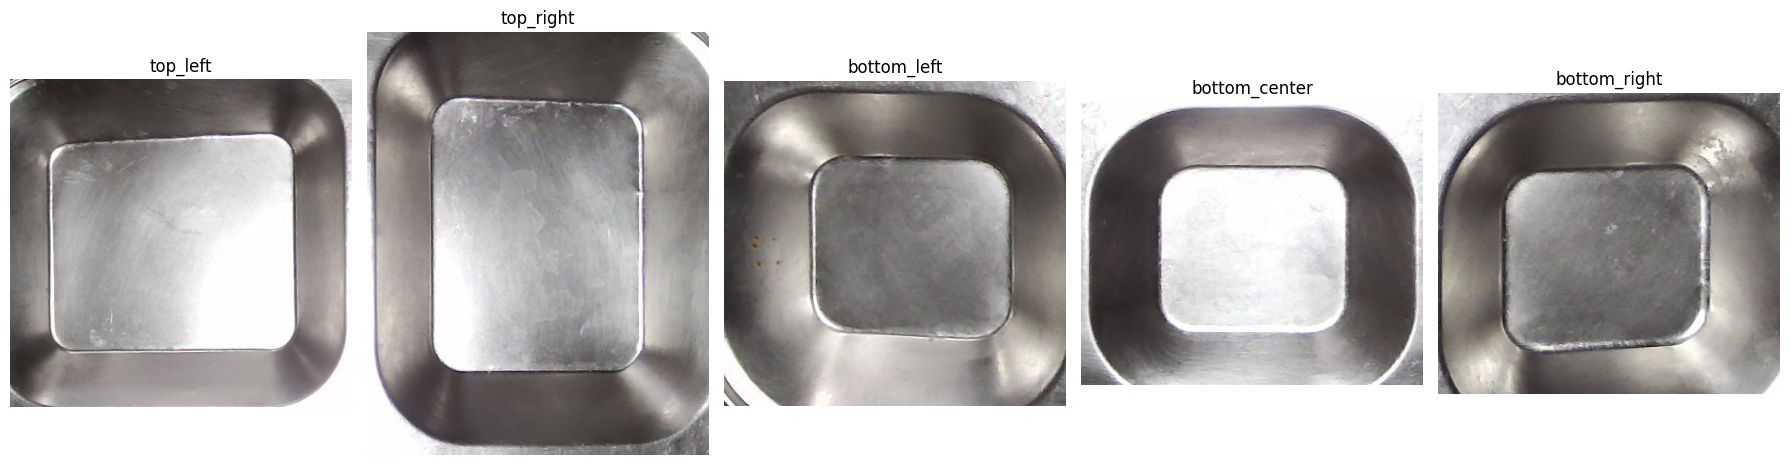

In [ ]:
# =========================
# TEST CẮT Ô KHAY TRÊN COLAB
# Khay 1: 3 ô trên + 2 ô dưới
# Khay 2: 2 ô trên + 3 ô dưới
# =========================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import os

# =========================
# 1. TỌA ĐỘ GỐC THEO ẢNH 1920x1080
# =========================

BASE_W = 1920
BASE_H = 1080

# KHAY 1: 3 ô trên + 2 ô dưới
TRAY_TYPE_1 = {
    "top_left":     (373, 138, 703, 435),
    "top_center":   (725, 116, 1094, 437),
    "top_right":    (1103, 117, 1454, 457),
    "bottom_left":  (357, 482, 782, 967),
    "bottom_right": (918, 478, 1455, 936),
}

# KHAY 2: 2 ô trên + 3 ô dưới
TRAY_TYPE_2 = {
    "top_left":       (392, 128, 902, 617),
    "top_right":      (1044, 136, 1440, 626),
    "bottom_left":    (369, 641, 696, 952),
    "bottom_center":  (720, 647, 1096, 958),
    "bottom_right":   (1113, 640, 1435, 924),
}


# =========================
# 2. HÀM SCALE TỌA ĐỘ THEO KÍCH THƯỚC ẢNH
# =========================

def scale_rois(rois, current_w, current_h, base_w=1920, base_h=1080):
    sx = current_w / base_w
    sy = current_h / base_h

    scaled = {}

    for name, (x1, y1, x2, y2) in rois.items():
        scaled[name] = (
            int(x1 * sx),
            int(y1 * sy),
            int(x2 * sx),
            int(y2 * sy)
        )

    return scaled


def get_rois(image_rgb, tray_type="tray1"):
    h, w = image_rgb.shape[:2]

    if tray_type == "tray1":
        rois = scale_rois(TRAY_TYPE_1, w, h)
    elif tray_type == "tray2":
        rois = scale_rois(TRAY_TYPE_2, w, h)
    else:
        raise ValueError("tray_type chỉ được là 'tray1' hoặc 'tray2'")

    return rois


# =========================
# 3. HÀM VẼ KHUNG DEBUG
# =========================

def draw_rois(image_rgb, rois):
    img_draw = image_rgb.copy()

    for name, (x1, y1, x2, y2) in rois.items():
        cv2.rectangle(
            img_draw,
            (x1, y1),
            (x2, y2),
            (255, 100, 0),
            5
        )

        cv2.putText(
            img_draw,
            name,
            (x1, max(35, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (255, 100, 0),
            3,
            cv2.LINE_AA
        )

    return img_draw


# =========================
# 4. HÀM CẮT TỪNG Ô
# =========================

def crop_cells(image_rgb, rois):
    crops = {}

    for name, (x1, y1, x2, y2) in rois.items():
        crop = image_rgb[y1:y2, x1:x2]
        crops[name] = crop

    return crops


def show_crops(crops):
    n = len(crops)

    plt.figure(figsize=(18, 6))

    for i, (name, crop) in enumerate(crops.items()):
        plt.subplot(1, n, i + 1)
        plt.imshow(crop)
        plt.title(name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# =========================
# 5. UPLOAD ẢNH
# =========================

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

image = Image.open(img_path).convert("RGB")
image_rgb = np.array(image)

print("Tên ảnh:", img_path)
print("Kích thước ảnh:", image_rgb.shape)

plt.figure(figsize=(14, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Ảnh gốc")
plt.show()


# =========================
# 6. CHỌN LOẠI KHAY
# =========================
# Khay 1: 3 ô trên + 2 ô dưới
# Khay 2: 2 ô trên + 3 ô dưới

tray_type = "tray2"     # đổi thành "tray2" nếu ảnh là khay loại 2


# =========================
# 7. VẼ KHUNG VÀ CẮT ẢNH
# =========================

rois = get_rois(image_rgb, tray_type)

print("Tọa độ sau khi scale:")
for name, box in rois.items():
    print(name, ":", box)

debug_img = draw_rois(image_rgb, rois)
crops = crop_cells(image_rgb, rois)

plt.figure(figsize=(14, 8))
plt.imshow(debug_img)
plt.axis("off")
plt.title(f"Debug crop - {tray_type}")
plt.show()

show_crops(crops)


